<a href="https://colab.research.google.com/github/keshav231897-dotcom/Netflix-Data-Analysis/blob/main/Netflix_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('/netflix_titles.csv')

rows,cols = df.shape
missing_total = df.isna().sum().sum()
duplicate_count = df.duplicated().sum()

print("5 line summary")
print(f"1.Dataset shape:The dataset contains exactly{rows}and{cols}columns")
print(f"2.Data types:The columns consist of text values and numeric numbers")
print(f"3.Missing Values:There are a total of{missing_total}empty data entries across all columns")
print(f"4.Duplicates:Found{duplicate_count}fully duplicated rows in this dataset")
print(f"5.Key Coontents:The dataset catalogs Netflix Shows,tracking directors,cast lists,and genres")


5 line summary
1.Dataset shape:The dataset contains exactly8807and12columns
2.Data types:The columns consist of text values and numeric numbers
3.Missing Values:There are a total of4307empty data entries across all columns
4.Duplicates:Found0fully duplicated rows in this dataset
5.Key Coontents:The dataset catalogs Netflix Shows,tracking directors,cast lists,and genres


In [ ]:
df['director']= df['director'].fillna('Unknown Director')
df['cast']= df['cast'].fillna('Unknown Cast')
df['country']=df['country'].fillna('Unknown Country')
df = df.dropna(subset=['date_added','rating','duration'])
df['date_added']=pd.to_datetime(df['date_added'].str.strip())
print("Data Cleaning Completion Report")
print(f"Remaining Missing values:{df.isna().sum().sum()}entries")
print(f"Cleaned datset shape:{df.shape[0]}rows remaning after dropping minor missing rows")
print(f"Data Type Check:'date_added'column successfully converted to {df['date_added'].dtype}")


Data Cleaning Completion Report
Remaining Missing values:0entries
Cleaned datset shape:8790rows remaning after dropping minor missing rows
Data Type Check:'date_added'column successfully converted to datetime64[ns]


In [ ]:
print("Exploratory data Analysis\n")
print("Q1: Statistical summary of numeric fields:")
print(df.describe())
print("-"*50)

print("\nQ2:Distribution of content typees on Netflix:")
print(df['type'].value_counts())
print("-"*50)

print("\nQ3: Content types segmented by country:")
known_countries=df[df['country']!='Unknown Country']
country_segments = known_countries.groupby(['country','type']).size().unstack(fill_value=0)
top_countries = country_segments.assign(total=country_segments.sum(axis=1)).sort_values(by='total',ascending=False)
print(top_countries.head(10))
print("-"*50)

print("\nQ4:Top 10 listed genres on netflix:")
genres = df['listed_in'].str.split(', ').explode()
print(genres.value_counts().head(10))
print("-"*50)

print("\nQ5: Content addition trend over the last 10 years:")
df['year_added']=df['date_added'].dt.year
print(df['year_added'].value_counts().sort_index().tail(10))
print("-"*50)


Exploratory data Analysis

Q1: Statistical summary of numeric fields:
                          date_added  release_year   year_added
count                           8790   8790.000000  8790.000000
mean   2019-05-17 21:44:01.638225408   2014.183163  2018.873606
min              2008-01-01 00:00:00   1925.000000  2008.000000
25%              2018-04-06 00:00:00   2013.000000  2018.000000
50%              2019-07-03 00:00:00   2017.000000  2019.000000
75%              2020-08-19 18:00:00   2019.000000  2020.000000
max              2021-09-25 00:00:00   2021.000000  2021.000000
std                              NaN      8.825466     1.573568
--------------------------------------------------

Q2:Distribution of content typees on Netflix:
type
Movie      6126
TV Show    2664
Name: count, dtype: int64
--------------------------------------------------

Q3: Content types segmented by country:
type            Movie  TV Show  total
country                              
United States    2055    

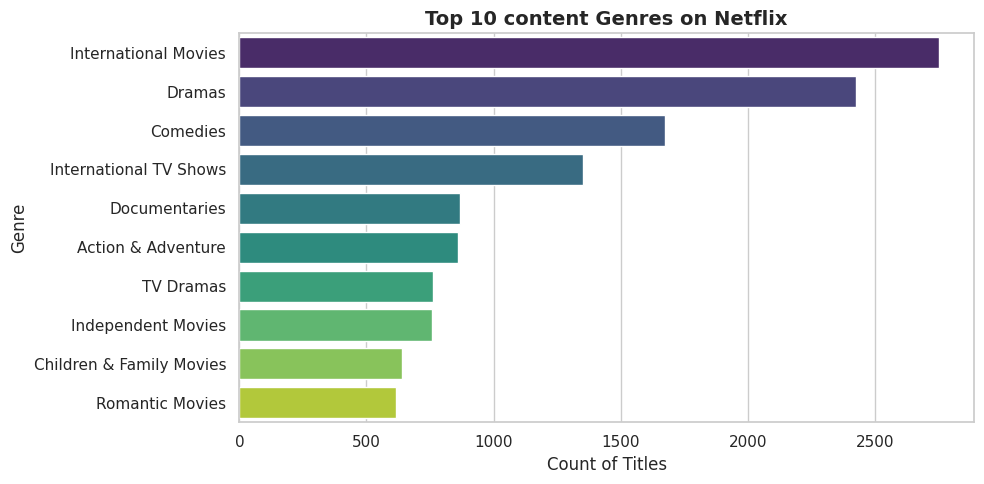

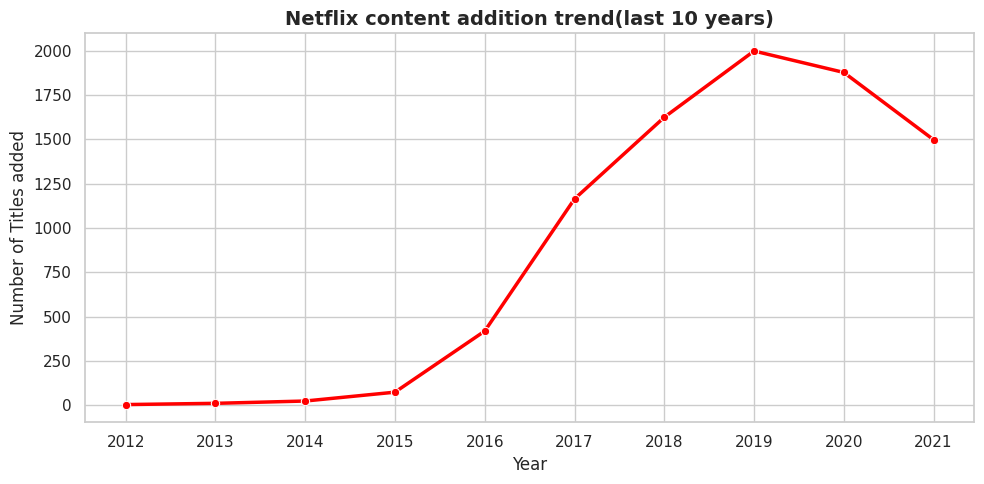

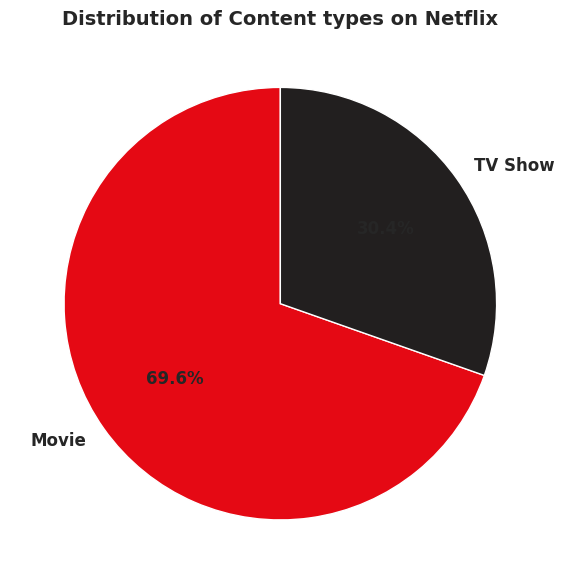

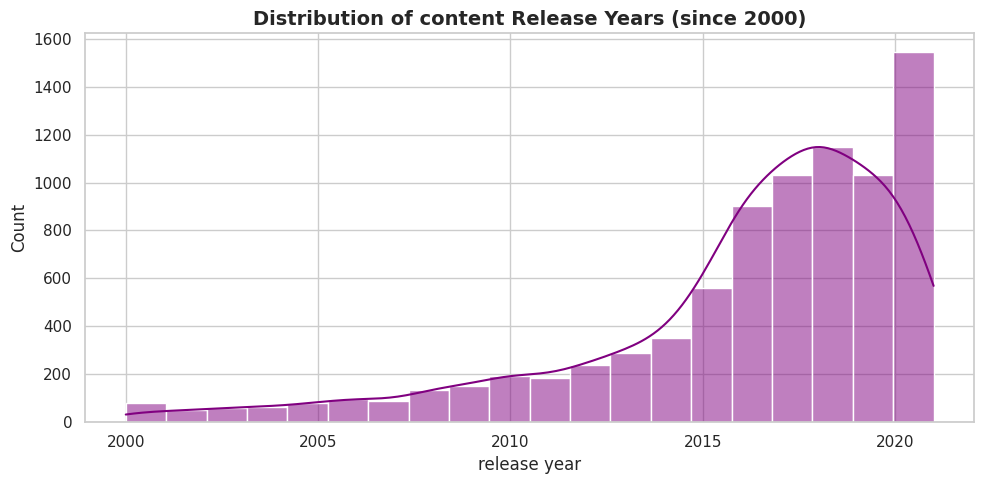

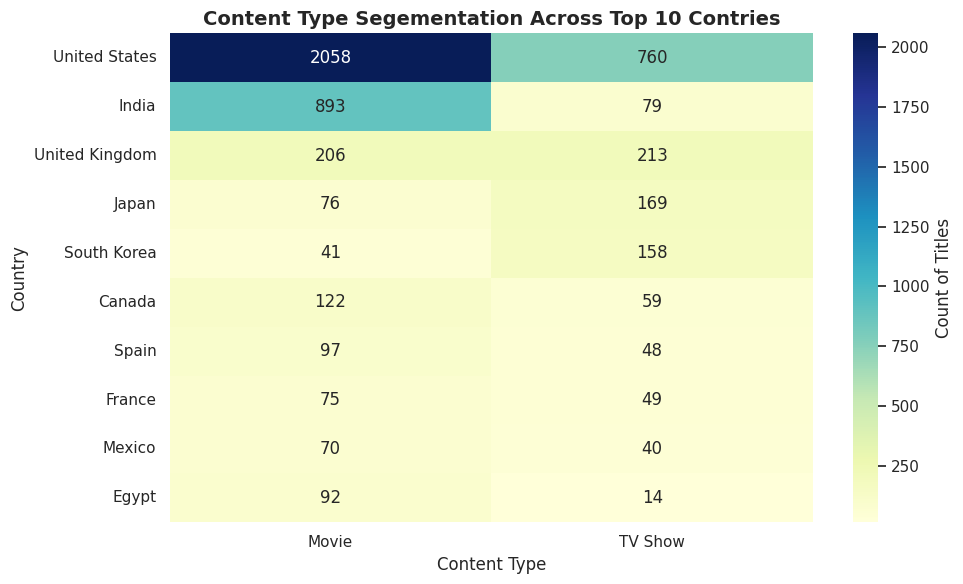

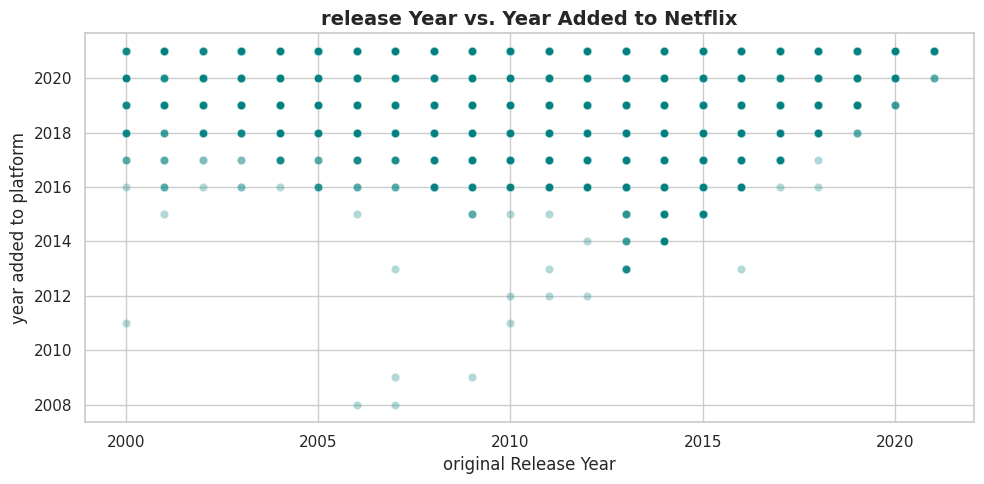

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
df=pd.read_csv('netflix_titles.csv')
df.columns=df.columns.str.strip()
df['year_added']=pd.to_datetime(df['date_added'],errors='coerce').dt.year
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,5))
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)
sns.barplot(x=top_genres.values,y=top_genres.index,hue=top_genres.index,palette="viridis",legend=False)
plt.title("Top 10 content Genres on Netflix",fontsize=14,fontweight='bold')
plt.xlabel("Count of Titles",fontsize=12)
plt.ylabel("Genre",fontsize=12)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
trend_data = df['year_added'].value_counts().sort_index().tail(10)
sns.lineplot(x=trend_data.index.astype(int),y=trend_data.values,marker="o",color="red",linewidth=2.5)
plt.title("Netflix content addition trend(last 10 years)",fontsize=14,fontweight='bold')
plt.xlabel("Year",fontsize=12)
plt.ylabel("Number of Titles added",fontsize=12)
plt.xticks(trend_data.index.astype(int))
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,6))
type_counts= df['type'].value_counts()
plt.pie(type_counts.values,labels=type_counts.index,autopct='%1.1f%%',colors=['#E50914','#221F1F'],startangle=90,textprops={'fontsize':12,'weight':'bold'})
plt.title("Distribution of Content types on Netflix",fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
recent_releases =df[df['release_year']>=2000]
sns.histplot(data=recent_releases,x="release_year",bins=20,kde=True,color="purple")
plt.title("Distribution of content Release Years (since 2000)",fontsize =14, fontweight='bold')
plt.xlabel("release year",fontsize =12)
plt.ylabel("Count",fontsize=12)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
known_countries =df[df['country']!='Unknown Country']
country_segments= known_countries.groupby(['country','type']).size().unstack(fill_value=0)
top_10_countries = country_segments.assign(total=country_segments.sum(axis=1)).sort_values(by='total',ascending=False).head(10)
heatmap_data = top_10_countries.drop(columns=['total'])
sns.heatmap(heatmap_data,annot=True,fmt="d",cmap="YlGnBu",cbar_kws={'label':'Count of Titles'})
plt.title("Content Type Segementation Across Top 10 Contries",fontsize=14,fontweight='bold')
plt.xlabel("Content Type",fontsize=12)
plt.ylabel("Country",fontsize=12)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
scatter_df=df[df['release_year']>=2000].dropna(subset=['year_added'])
sns.scatterplot(data=scatter_df,x="release_year",y="year_added",alpha=0.3,color="teal")
plt.title("release Year vs. Year Added to Netflix",fontsize=14,fontweight ='bold')
plt.xlabel("original Release Year",fontsize=12)
plt.ylabel("year added to platform",fontsize=12)
plt.tight_layout()
plt.show()

#Insights Report

1.Key Data Insights Found
* **Content Formats:** Movies from the vast majority of Netflix's library at approximately **69.6%** while TV shows occupy the remaining **30.4%**.This shows a historical focus on standalone feature content over multi-episode series
* **Genre Dominance:** International Movies,Dramas,and Comedian are the clear pillars of user engagement,significantly outperforming highly niche categories like Documentaries or Action and Adventure.
* **Geographic Distribution:** The United States
leads as the primary content provider by a wide
margin,with India exhibiting a massive emphasis on feature films over serialized Tv content
* **Historical Growth Curve:** Platform additions remained low  from 2012 to 2015,followed by exponential growth that peaked heavily in 2019. Post-2019 shows a gradual decline in annual ingestion rates, likely due to
changing licensing conditions and production adjustments.
* **Operational Shifting:** The sharp decline in raw catalog entry growth post-2019 directly demonstrates a clear tarnsition toward original,high-quality production models over massive, third-party volume licensing applications

2.Strategic Business Recommendations
* **Balance Content Formats:** Because TV shows have massive audience retention benefits through multi-week viewing cycles,Netflix should incrementally increase its investment in original episodic TV series to optimize subscriber retention rates.
* **Target Regional Hubs:** Content production resources should lean heavily into regions with highly successful catalog footprints(such as the US,India,and the UK)to capture reliable regional viewership metrics.
* **Revitalize Legacy Genres:** Classic content clusters like independent cinema or specialized action titles could represent untapped niches that can be scaled effectively with strategic promotional focus.

#Most Surprising Finding
What surprised me the most was looking at the historiical growth trend chart.I expectted content additions to keep climbing steadily every single year up to the present day, but the data clearly shows a sharp drop after 2019.This reveals that Netflix actively shifted its business strategy away from a pure volume ingestion toward a more selective catalog